# Predicting Asteroid Diameter Using a Decision Tree

**Dataset:** JPL Small-Body Database — `asteroid.csv`  
**Target Variable:** `diameter` (kilometres)  
**Task:** Regression using a Decision Tree model

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

---
## 1. Data Cleaning
**Steps covered:** missing value treatment, duplicate row removal

In [23]:
# I load the raw asteroid dataset first so I can inspect quality issues early.
asteroid_df = pd.read_csv('project-dataset/asteroid data and description/asteroid.csv', low_memory=False)

print(f"Original shape: {asteroid_df.shape}")
print(f"\nMissing values per column (top 15):")
print(asteroid_df.isnull().sum().sort_values(ascending=False).head(15))

Original shape: (958524, 45)

Missing values per column (top 15):
prefix            958506
name              936460
albedo            823421
diameter_sigma    822443
diameter          822315
sigma_per          19926
sigma_ad           19926
sigma_om           19922
sigma_ma           19922
sigma_q            19922
sigma_a            19922
sigma_w            19922
sigma_i            19922
sigma_tp           19922
sigma_e            19922
dtype: int64


In [24]:
# --- Step 1: Remove duplicate rows ---
duplicate_rows_before = asteroid_df.duplicated().sum()
asteroid_df = asteroid_df.drop_duplicates()
print(f"Duplicate rows removed: {duplicate_rows_before}")
print(f"Shape after removing duplicates: {asteroid_df.shape}")

Duplicate rows removed: 0
Shape after removing duplicates: (958524, 45)


In [25]:
# --- Step 2: Drop rows where the target variable (diameter) is missing ---
# I avoid imputing the target variable because that would inject artificial labels.
row_count_before_target_drop = len(asteroid_df)
asteroid_df = asteroid_df.dropna(subset=['diameter'])
print(f"Rows dropped (missing diameter): {row_count_before_target_drop - len(asteroid_df)}")
print(f"Shape after dropping missing target: {asteroid_df.shape}")

Rows dropped (missing diameter): 822315
Shape after dropping missing target: (136209, 45)


In [26]:
# --- Step 3: Drop non-predictive columns ---
# My intention here is to keep only features that can reasonably help diameter prediction.
columns_to_drop = [
    'id', 'spkid', 'full_name', 'pdes', 'name', 'prefix',   # identifiers / names
    'orbit_id', 'equinox',                                    # metadata
    'epoch', 'epoch_mjd', 'epoch_cal',                        # reference epoch (redundant)
    'tp', 'tp_cal',                                           # time of perihelion (redundant with per)
    'diameter_sigma',                                         # uncertainty on the target, not a predictor
]

# Drop all sigma_* uncertainty columns — they describe fit uncertainty, not core physical traits.
sigma_columns = [column_name for column_name in asteroid_df.columns if column_name.startswith('sigma_')]
columns_to_drop += sigma_columns

asteroid_df = asteroid_df.drop(columns=[column_name for column_name in columns_to_drop if column_name in asteroid_df.columns])
print(f"Columns dropped: {len(columns_to_drop)}")
print(f"Remaining columns ({asteroid_df.shape[1]}): {list(asteroid_df.columns)}")

Columns dropped: 25
Remaining columns (20): ['neo', 'pha', 'H', 'diameter', 'albedo', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'per', 'per_y', 'moid', 'moid_ld', 'class', 'rms']


In [27]:
# --- Step 4: Treat remaining missing values ---
# Numeric columns: median (more robust to skew/outliers)
# Categorical columns: mode (most frequent class)

numeric_columns = asteroid_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = asteroid_df.select_dtypes(exclude=[np.number]).columns.tolist()

for column_name in numeric_columns:
    asteroid_df[column_name] = asteroid_df[column_name].fillna(asteroid_df[column_name].median())

for column_name in categorical_columns:
    asteroid_df[column_name] = asteroid_df[column_name].fillna(asteroid_df[column_name].mode()[0])

print(f"Remaining missing values after imputation: {asteroid_df.isnull().sum().sum()}")
print(f"Final cleaned dataset shape: {asteroid_df.shape}")

Remaining missing values after imputation: 0
Final cleaned dataset shape: (136209, 20)


---
## 2. Categorical Encoding
Three categorical columns require encoding before modelling: `neo`, `pha`, and `class`.

In [28]:
# I keep encoders separate to make each transformation intention obvious.
binary_label_encoder = LabelEncoder()

# neo and pha are binary Y/N flags, so integer encoding is sufficient here.
asteroid_df['neo'] = binary_label_encoder.fit_transform(asteroid_df['neo'])
print("neo encoding — classes:", list(binary_label_encoder.classes_), "→ mapped to:", list(range(len(binary_label_encoder.classes_))))

asteroid_df['pha'] = binary_label_encoder.fit_transform(asteroid_df['pha'])
print("pha encoding — classes:", list(binary_label_encoder.classes_), "→ mapped to:", list(range(len(binary_label_encoder.classes_))))

# class has multiple orbital categories → encode into integer labels.
orbit_class_encoder = LabelEncoder()
asteroid_df['class'] = orbit_class_encoder.fit_transform(asteroid_df['class'])
print("\nclass encoding mapping:")
for class_code, class_label in enumerate(orbit_class_encoder.classes_):
    print(f"  {class_code} → {class_label}")

neo encoding — classes: ['N', 'Y'] → mapped to: [0, 1]
pha encoding — classes: ['N', 'Y'] → mapped to: [0, 1]

class encoding mapping:
  0 → AMO
  1 → APO
  2 → AST
  3 → ATE
  4 → CEN
  5 → IMB
  6 → MBA
  7 → MCA
  8 → OMB
  9 → TJN
  10 → TNO


In [29]:
print("\nData types after encoding:")
print(asteroid_df.dtypes)
print("\nFirst 3 rows (encoded):")
asteroid_df.head(3)


Data types after encoding:
neo           int64
pha           int64
H           float64
diameter    float64
albedo      float64
e           float64
a           float64
q           float64
i           float64
om          float64
w           float64
ma          float64
ad          float64
n           float64
per         float64
per_y       float64
moid        float64
moid_ld     float64
class         int64
rms         float64
dtype: object

First 3 rows (encoded):


,neo,pha,H,diameter,albedo,e,a,q,i,om,w,ma,ad,n,per,per_y,moid,moid_ld,class,rms
0,0,0,3.40,939.400,0.090,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,2.979647,0.213885,1683.145703,4.608202,1.59478,620.640533,6,0.43301
1,0,0,4.20,545.000,0.101,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,3.411748,0.213345,1687.410992,4.619880,1.23429,480.348639,6,0.35936
2,0,0,5.33,246.596,0.214,0.256936,2.668285,1.982706,12.991043,169.851482,248.066193,125.435355,3.353865,0.226129,1592.013769,4.358696,1.03429,402.514639,6,0.33848


---
## 3. Feature Selection
`SelectKBest` with the `f_regression` scorer ranks features by their F-statistic with respect to `diameter`. The top 10 features are retained.

In [30]:
# Separate predictors from target
feature_matrix = asteroid_df.drop(columns=['diameter'])
target_diameter = asteroid_df['diameter']

candidate_feature_names = feature_matrix.columns.tolist()
print(f"Total candidate features: {len(candidate_feature_names)}")
print(candidate_feature_names)

Total candidate features: 19
['neo', 'pha', 'H', 'albedo', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'per', 'per_y', 'moid', 'moid_ld', 'class', 'rms']


In [31]:
# Apply SelectKBest — retain the 10 features most linearly related to diameter
feature_selector = SelectKBest(score_func=f_regression, k=10)
feature_selector.fit(feature_matrix, target_diameter)

# Build a compact scoring summary I can inspect and report.
feature_scores_df = pd.DataFrame({
    'Feature': candidate_feature_names,
    'F-Score': feature_selector.scores_,
    'Selected': feature_selector.get_support()
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

print("Feature Selection Results (sorted by F-Score):")
print(feature_scores_df.to_string(index=False))

Feature Selection Results (sorted by F-Score):
Feature      F-Score  Selected
      H 66272.580665      True
   moid 16871.178865      True
moid_ld 16871.178865      True
      q 16557.846457      True
      n  5641.341759      True
    rms  4683.357338      True
  class  4120.836309      True
      a  2999.883073      True
 albedo  1599.119332      True
     ad  1233.486405      True
      i   412.720789     False
      e   350.318385     False
  per_y   345.241968     False
    per   345.241968     False
    neo   181.169271     False
    pha    52.743449     False
      w     1.321772     False
     ma     1.076228     False
     om     0.318874     False


In [32]:
# Keep selected feature names for charts and tree labels later.
top_feature_names = feature_scores_df[feature_scores_df['Selected'] == True]['Feature'].tolist()
print(f"\nSelected features ({len(top_feature_names)}):")
print(top_feature_names)


Selected features (10):
['H', 'moid', 'moid_ld', 'q', 'n', 'rms', 'class', 'a', 'albedo', 'ad']


---
## 4. Plot of Selected Features
A horizontal bar chart of SelectKBest F-scores for all features, with selected features highlighted.

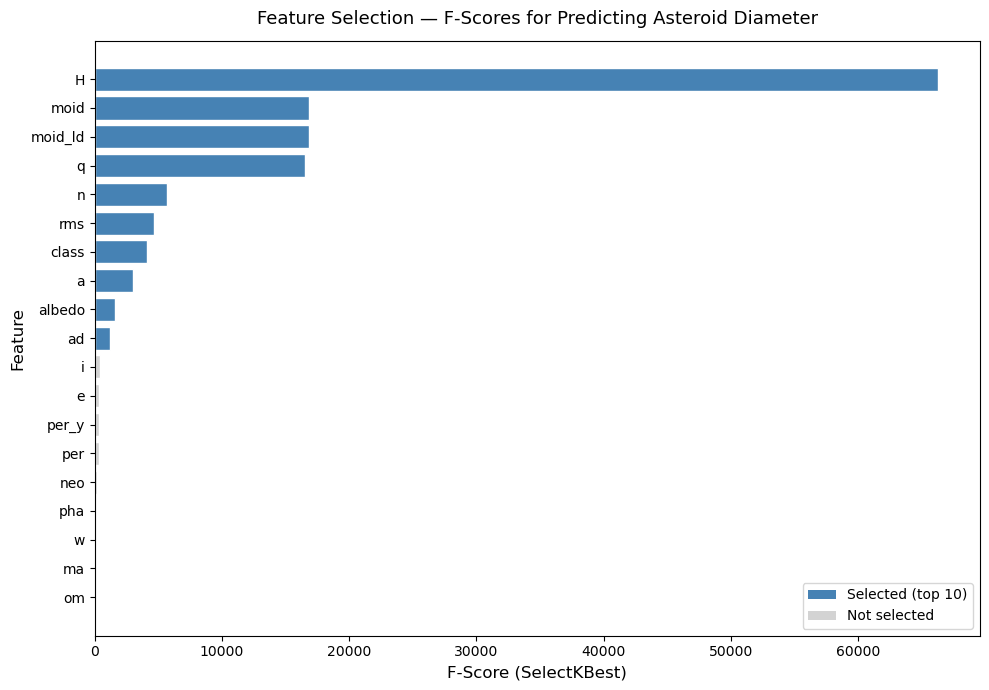

Plot saved as feature_selection_scores.png


In [33]:
fig, ax = plt.subplots(figsize=(10, 7))

bar_colors = ['steelblue' if selected_flag else 'lightgrey' for selected_flag in feature_scores_df['Selected']]

bars = ax.barh(feature_scores_df['Feature'], feature_scores_df['F-Score'], color=bar_colors, edgecolor='white')

# Legend clarifies selected vs non-selected features visually.
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor='steelblue', label='Selected (top 10)'),
    Patch(facecolor='lightgrey', label='Not selected')
]
ax.legend(handles=legend_items, loc='lower right')

ax.set_xlabel('F-Score (SelectKBest)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Feature Selection — F-Scores for Predicting Asteroid Diameter', fontsize=13, pad=12)
ax.invert_yaxis()   # highest score at the top

plt.tight_layout()
plt.savefig('feature_selection_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as feature_selection_scores.png")

---
## 5. Feature Scaling
`StandardScaler` standardises each selected feature to zero mean and unit variance.

In [34]:
# Extract only the selected features
selected_features_array = feature_selector.transform(feature_matrix)
selected_features_df = pd.DataFrame(selected_features_array, columns=top_feature_names)

print("Before scaling — mean and std of first 3 selected features:")
print(selected_features_df[top_feature_names[:3]].agg(['mean', 'std']).round(4))

Before scaling — mean and std of first 3 selected features:
            H    moid  moid_ld
mean  15.1344  0.1302   2.8192
std    1.3666  0.1100   1.4960


In [35]:
standard_scaler = StandardScaler()
scaled_features_array = standard_scaler.fit_transform(selected_features_df)
scaled_features_df = pd.DataFrame(scaled_features_array, columns=top_feature_names)

print("After scaling — mean and std of first 3 selected features:")
print(scaled_features_df[top_feature_names[:3]].agg(['mean', 'std']).round(6))
print("\n(Mean ≈ 0 and Std ≈ 1 confirms successful standardisation)")

After scaling — mean and std of first 3 selected features:
             H      moid   moid_ld
mean -0.000000  0.000000  0.000000
std   1.000004  1.000004  1.000004

(Mean ≈ 0 and Std ≈ 1 confirms successful standardisation)


---
## 6. Train/Test Split
80% of data used for training, 20% held out for testing. `random_state=42` ensures reproducibility.

In [36]:
X_train_set, X_test_set, y_train_set, y_test_set = train_test_split(
    scaled_features_array, target_diameter.values, test_size=0.2, random_state=42
)

print(f"Training set:   X_train {X_train_set.shape}  |  y_train {y_train_set.shape}")
print(f"Testing set:    X_test  {X_test_set.shape}   |  y_test  {y_test_set.shape}")

Training set:   X_train (108967, 10)  |  y_train (108967,)
Testing set:    X_test  (27242, 10)   |  y_test  (27242,)


---
## 7. Fit the Decision Tree Model
`DecisionTreeRegressor` is trained on the training data. `max_depth=5` is set to control overfitting on the large dataset.

In [37]:
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_model.fit(X_train_set, y_train_set)

print(f"Decision Tree fitted successfully.")
print(f"  Actual tree depth : {tree_model.get_depth()}")
print(f"  Number of leaves  : {tree_model.get_n_leaves()}")
print(f"  Number of features: {tree_model.n_features_in_}")

Decision Tree fitted successfully.
  Actual tree depth : 5
  Number of leaves  : 27
  Number of features: 10


---
## 8. Model Performance Evaluation
Four metrics are reported: MSE, RMSE, MAE, and R².

In [38]:
predicted_diameter = tree_model.predict(X_test_set)

mean_sq_error = mean_squared_error(y_test_set, predicted_diameter)
root_mean_sq_error = np.sqrt(mean_sq_error)
mean_abs_error = mean_absolute_error(y_test_set, predicted_diameter)
r2_value = r2_score(y_test_set, predicted_diameter)

metrics_table = pd.DataFrame({
    'Metric': ['Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)',
               'Mean Absolute Error (MAE)', 'R² Score'],
    'Value': [round(mean_sq_error, 4), round(root_mean_sq_error, 4), round(mean_abs_error, 4), round(r2_value, 4)]
})

print(metrics_table.to_string(index=False))

                        Metric   Value
      Mean Squared Error (MSE) 10.3709
Root Mean Squared Error (RMSE)  3.2204
     Mean Absolute Error (MAE)  1.1494
                      R² Score  0.8972


**Interpretation:** The R² score indicates the proportion of variance in asteroid diameter that the model explains. A value close to 1.0 means the model fits the data well. RMSE and MAE are expressed in kilometres and represent the average prediction error.

---
## 9. Decision Tree Visualisation
The tree is plotted to a depth of 3 levels for readability (full depth is 5).

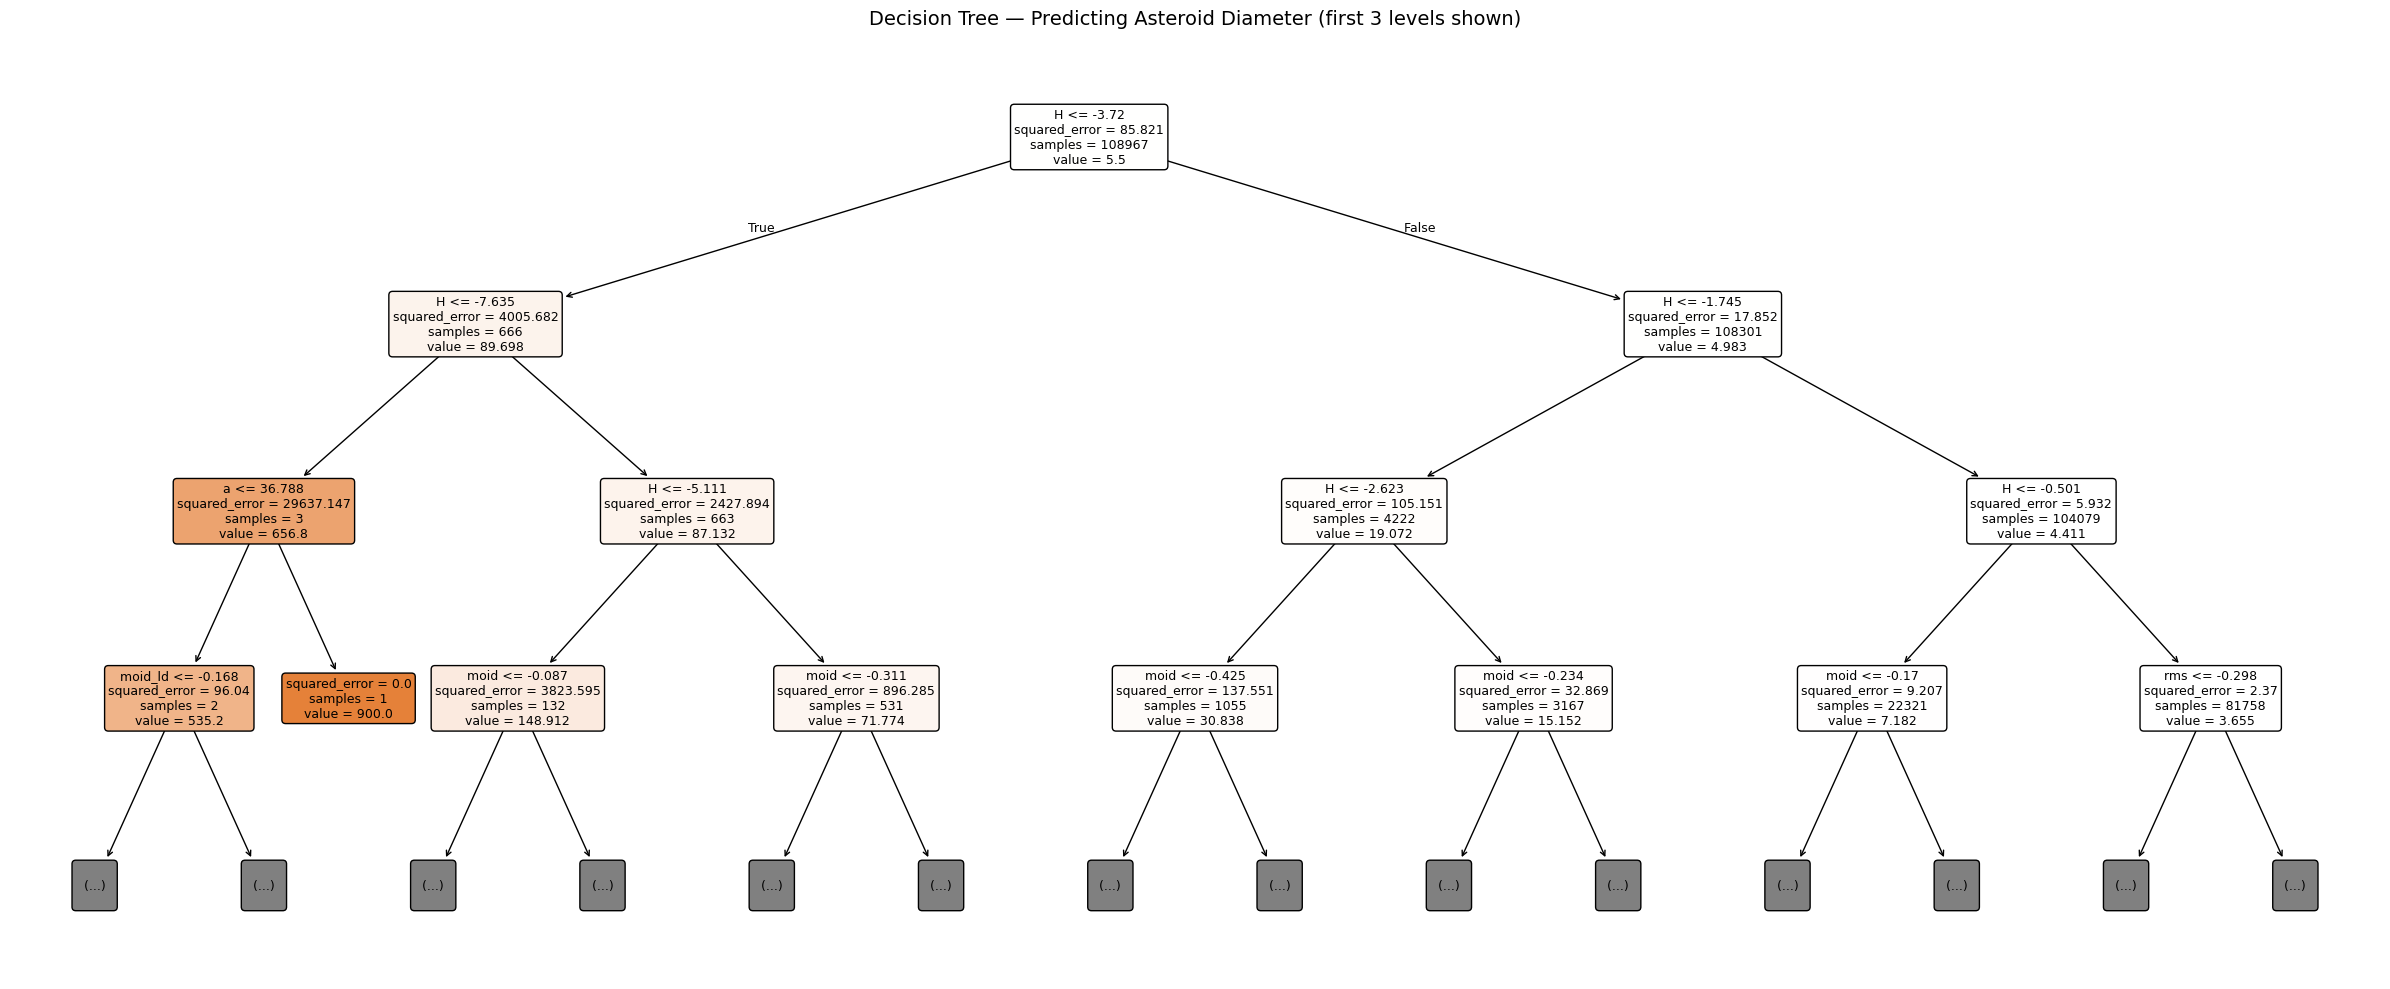

Decision tree plot saved as decision_tree.png


In [39]:
fig, ax = plt.subplots(figsize=(24, 10))

plot_tree(
    tree_model,
    max_depth=3,
    feature_names=top_feature_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)

ax.set_title('Decision Tree — Predicting Asteroid Diameter (first 3 levels shown)', fontsize=14, pad=14)

plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Decision tree plot saved as decision_tree.png")